# Cross-Modal Diagnostic Observability — Stage 11G-R

## Development-only DDO-2 decisive viability kill test

This notebook is the terminal development feasibility test for **DDO-2 v0.1**, not another data-acquisition stage. It starts from the sealed Stage 11F-R 30-edge library and asks the question that matters before any more dataset repair or expansion:

> Do the Stage 9 frozen discrimination features predict out-of-group discrimination failure under both leave-one-dataset-out and leave-one-modality-out evaluation?

The calibration and operating-point axes are not fitted because their frozen Stage 9 class-balance gates failed. The discrimination axis passed every frozen class-balance and modality-class gate and is therefore the only axis eligible for this viability test.

### Pre-run decision rule

The DDO-2 v0.1 predictive-law route is retained only if the frozen discrimination feature set clears every development viability gate in this notebook. Otherwise the route is terminated and no more development datasets should be acquired solely to repair class counts. This rule is a post-Stage-11F development decision protocol, not prospective blind evidence.

### Firewall

- no Stage 12 operation;
- no locked-blind asset access;
- no target-model or source-axis refit;
- no edge deletion or outcome relabelling;
- no feature selection or hyperparameter search; and
- no calibration or operating-point coefficient fit.

CPU is sufficient. Run all six code cells from top to bottom.


In [1]:
# @title 11G-R-0. Mount Drive, verify the sealed 30-edge parent, and freeze the kill-test protocol
import hashlib, json, os, platform, sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    pass

DEFAULT_ROOT = Path('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability') if IN_COLAB else Path('/tmp/Cross-Modal_Diagnostic_Observability')
PROJECT_ROOT = Path(os.environ.get('CDO_PROJECT_ROOT', str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT/'05_Code'/'Cross_Modal'
CM_ROOT = PROJECT_ROOT/'06_Data_Records'/'Cross_Modal'
PARENT_ROOT = CM_ROOT/'Stage11F-R_Development_Only_Directed_Edge_Assembly_And_Fit_Readiness_v0.2'
ROOT = CM_ROOT/'Stage11G-R_Development_Only_DDO2_Decisive_Viability_Kill_Test_v0.1'
P0,P1,P2,P3,P4 = [ROOT/x for x in ['00_Protocol','01_Grouped_Predictions','02_Uncertainty_And_Baselines','03_Firewall','04_Results']]
for p in [CODE_ROOT,P0,P1,P2,P3,P4]: p.mkdir(parents=True,exist_ok=True)

NOTEBOOK_NAME='CrossModal_Stage11G-R_Development_Only_DDO2_Decisive_Viability_Kill_Test_v0.1.ipynb'
NOTEBOOK_PATH=CODE_ROOT/NOTEBOOK_NAME
PARENT_FINAL=PARENT_ROOT/'06_Results'/'Stage11F-R_Complete_v0.2.json'
PARENT_LIBRARY=PARENT_ROOT/'03_Expanded_Edge_Library'/'Stage11F-R_FourModality_Eligible_Edge_Library_v0.2.csv'
PARENT_FIT_AUDIT=PARENT_ROOT/'04_Independence_And_Readiness'/'Stage11F-R_DDO2_Fit_Eligibility_Audit_v0.2.csv'

EXPECTED_PARENT_FINAL='bfe88b0b57d9efc90a123995d606648e9074eecb17d951087caaf4a889514423'
EXPECTED_LIBRARY='f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9'
EXPECTED_FIT_AUDIT='5d1e5d045a3dff69f7888e1d118ccfff79ec9760c9dd92cb44fbf3d69f3eece0'
EXPECTED_ROWS=30; EXPECTED_MODALITIES=4; EXPECTED_DATASETS=14
SEED=20260722; N_BOOTSTRAP=2000; N_PERMUTATIONS=1000

DDO_FEATURES=['support_fraction','fraction_beyond_source_q99','atc_estimated_accuracy']
AUDIT_BASELINE_FEATURES=['domain_auc','rbf_mmd2','ot_cosine_cost','mixture_wasserstein_residual_normalised']
ALL_REQUIRED=DDO_FEATURES+AUDIT_BASELINE_FEATURES+['edge_id','modality','source','target','discrimination_pass','calibration_pass','operating_point_pass']
VIABILITY_THRESHOLDS={
    'minimum_auc_each_scheme':0.60,
    'minimum_auc_at_least_one_scheme':0.65,
    'maximum_permutation_p_each_scheme':0.10,
    'minimum_mean_auc_advantage_over_audit_baseline':0.05,
    'minimum_auc_advantage_each_scheme':-0.02,
    'minimum_cluster_ci_lower_at_least_one_scheme':0.50,
}

PROTOCOL=P0/'Stage11G-R_Decisive_Viability_Protocol_Seal_v0.1.json'
PARENT_COMMIT=P0/'Stage11G-R_Parent_Input_Commitment_v0.1.csv'
ENVIRONMENT=P0/'Stage11G-R_Execution_Environment_v0.1.json'
PREDICTIONS=P1/'Stage11G-R_Grouped_OutOfGroup_Predictions_v0.1.csv'
PERFORMANCE=P1/'Stage11G-R_Grouped_Performance_Summary_v0.1.csv'
BOOTSTRAP=P2/'Stage11G-R_TwoWay_Dataset_Cluster_Bootstrap_v0.1.csv'
PERMUTATION=P2/'Stage11G-R_ModalityStratified_Permutation_Audit_v0.1.csv'
GATES=P2/'Stage11G-R_Decisive_Viability_Gates_v0.1.csv'
DECISION=P2/'Stage11G-R_Decisive_Viability_Decision_v0.1.json'
FIREWALL=P3/'Stage11G-R_Independent_Validity_And_Firewall_Checks_v0.1.csv'
REPORT=P4/'Stage11G-R_DDO2_Decisive_Viability_Report_v0.1.md'
FIGURE=P4/'Stage11G-R_DDO2_Decisive_Viability_v0.1.png'
MANIFEST=P4/'Stage11G-R_Output_Integrity_Manifest_v0.1.csv'
FINAL=P4/'Stage11G-R_Complete_v0.1.json'
RUNTIME=P4/'Stage11G-R_Runtime_State_v0.1.json'

def now(): return datetime.now(timezone.utc).isoformat()
def sha_file(p):
    h=hashlib.sha256()
    with Path(p).open('rb') as f:
        for b in iter(lambda:f.read(1024*1024),b''): h.update(b)
    return h.hexdigest()
def sha_json(x): return hashlib.sha256(json.dumps(x,sort_keys=True,separators=(',',':'),ensure_ascii=False).encode()).hexdigest()
def canon(df): return df.fillna('').to_csv(index=False,lineterminator='\n',float_format='%.12g')
def write_text(p,s):
    p=Path(p)
    if p.exists(): assert p.read_text(encoding='utf-8')==s,f'Replay mismatch: {p}'
    else: p.write_text(s,encoding='utf-8')
def write_csv(p,df): write_text(p,canon(df))
def write_json(p,x): write_text(p,json.dumps(x,indent=2,ensure_ascii=False)+'\n')
def verify_self(p,field,expected=None):
    x=json.loads(Path(p).read_text(encoding='utf-8')); claim=x[field]; y=dict(x); y.pop(field)
    assert sha_json(y)==claim,f'Self-hash mismatch: {p}'
    if expected is not None: assert claim==expected,f'Unexpected hash: {p}'
    return x
def seal(p,payload,field,time_field):
    if Path(p).exists():
        x=verify_self(p,field)
        for k,v in payload.items(): assert x[k]==v,f'Sealed field changed: {k}'
        return x
    x=dict(payload); x[time_field]=now(); x[field]=sha_json(x); write_json(p,x); return x
def notebook_source_hash(p):
    nb=json.loads(Path(p).read_text(encoding='utf-8')); payload=[]
    for c in nb.get('cells',[]):
        if c.get('cell_type') in {'code','markdown'}:
            s=c.get('source',[]); s=''.join(s) if isinstance(s,list) else str(s)
            payload.append({'cell_type':c['cell_type'],'source':s.replace('\r\n','\n')})
    return sha_json(payload)
def mdtable(df):
    x=df.fillna('').astype(str); esc=lambda s:str(s).replace('|','\\|').replace('\n',' ')
    return '\n'.join(['| '+' | '.join(map(esc,x.columns))+' |','| '+' | '.join('---' for _ in x.columns)+' |']+['| '+' | '.join(map(esc,r))+' |' for r in x.itertuples(index=False,name=None)])

required=[NOTEBOOK_PATH,PARENT_FINAL,PARENT_LIBRARY,PARENT_FIT_AUDIT]
missing=[str(p) for p in required if not Path(p).is_file()]
assert not missing,'Missing sealed inputs:\n'+'\n'.join(missing)
parent=verify_self(PARENT_FINAL,'final_record_sha256',EXPECTED_PARENT_FINAL)
assert sha_file(PARENT_LIBRARY)==EXPECTED_LIBRARY==parent['expanded_library_sha256']
assert sha_file(PARENT_FIT_AUDIT)==EXPECTED_FIT_AUDIT==parent['fit_eligibility_sha256']
assert parent['eligible_edges_total']==EXPECTED_ROWS and parent['modalities_total']==EXPECTED_MODALITIES and parent['unique_datasets_total']==EXPECTED_DATASETS
assert parent['stage11g_r_development_only_fit_authorised'] is False and parent['ddo2_fitted'] is False
assert parent['stage12_authorised'] is False and parent['locked_blind_assets_touched'] is False

edges=pd.read_csv(PARENT_LIBRARY); audit=pd.read_csv(PARENT_FIT_AUDIT)
assert len(edges)==EXPECTED_ROWS and edges.edge_id.is_unique and set(ALL_REQUIRED).issubset(edges.columns)
assert edges[ALL_REQUIRED].notna().all().all()
failed=audit.loc[~audit.passed.astype(bool),['scope','gate','observed','required']].to_dict('records')
assert failed==[
    {'scope':'calibration','gate':'minimum_passes','observed':4,'required':6},
    {'scope':'operating_point','gate':'minimum_passes','observed':3,'required':6},
    {'scope':'operating_point','gate':'pass_class_modalities','observed':1,'required':2},
]
commit=pd.DataFrame([{'role':p.name,'relative_path':str(p.relative_to(PROJECT_ROOT)),'size_bytes':p.stat().st_size,'sha256':sha_file(p)} for p in required[1:]])
write_csv(PARENT_COMMIT,commit)
payload={
    'stage':'Stage11G-R','version':'0.1','scope':'DEVELOPMENT_ONLY_DECISIVE_DDO2_V0_1_VIABILITY_KILL_TEST',
    'chronology':'protocol designed after Stage11F-R development outcomes; not prospective blind evidence',
    'parent_stage11f_r_final_sha256':parent['final_record_sha256'],'parent_library_sha256':sha_file(PARENT_LIBRARY),
    'parent_fit_audit_sha256':sha_file(PARENT_FIT_AUDIT),'notebook_source_sha256':notebook_source_hash(NOTEBOOK_PATH),
    'eligible_axis':'discrimination','ineligible_axes':['calibration','operating_point'],
    'primary_features':DDO_FEATURES,'audit_baseline_features':AUDIT_BASELINE_FEATURES,
    'model':'fixed C=1 class-balanced L2 logistic regression after training-fold robust scaling; no tuning',
    'validation':['leave-one-dataset-out with incident-edge exclusion and edge-level paired prediction averaging','leave-one-modality-out'],
    'uncertainty':'modality-stratified two-way source/target dataset cluster bootstrap on fixed out-of-group predictions',
    'permutation':'outcomes permuted within modality; complete grouped prediction pipeline refitted',
    'bootstrap_replicates':N_BOOTSTRAP,'permutation_replicates':N_PERMUTATIONS,'viability_thresholds':VIABILITY_THRESHOLDS,
    'ddo2_hierarchical_coefficients_fitted':False,'stage12_authorised':False,'locked_blind_assets_authorised':False,
}
protocol=seal(PROTOCOL,payload,'seal_sha256','sealed_utc')
env={'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,'pandas':pd.__version__,'protocol_seal_sha256':protocol['seal_sha256']}
if ENVIRONMENT.exists(): assert json.loads(ENVIRONMENT.read_text())['protocol_seal_sha256']==protocol['seal_sha256']
else: write_json(ENVIRONMENT,env)
runtime={'stage':'Stage11G-R','replay_mode':FINAL.exists(),'parent_rows':len(edges),'blind_accessed':False,'stage12_accessed':False,'hierarchical_ddo2_fitted':False}
RUNTIME.write_text(json.dumps(runtime,indent=2)+'\n')
print('Stage 11F-R final verified:',parent['final_record_sha256'])
print('Edges / modalities / datasets:',len(edges),edges.modality.nunique(),len(set(edges.source)|set(edges.target)))
print('Original failed full-fit gates:',failed)
print('Protocol seal:',protocol['seal_sha256'])
print('Eligible kill-test axis: discrimination only')


Mounted at /content/drive
Stage 11F-R final verified: bfe88b0b57d9efc90a123995d606648e9074eecb17d951087caaf4a889514423
Edges / modalities / datasets: 30 4 14
Original failed full-fit gates: [{'scope': 'calibration', 'gate': 'minimum_passes', 'observed': 4, 'required': 6}, {'scope': 'operating_point', 'gate': 'minimum_passes', 'observed': 3, 'required': 6}, {'scope': 'operating_point', 'gate': 'pass_class_modalities', 'observed': 1, 'required': 2}]
Protocol seal: 09c5ad0a7dbba2fe5b27feb1d22692185b68c761591ac08d209892c6e6ebc96d
Eligible kill-test axis: discrimination only


In [2]:
# @title 11G-R-1. Produce fixed leave-one-dataset-out and leave-one-modality-out predictions
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss,log_loss

edges=pd.read_csv(PARENT_LIBRARY).copy()
edges['discrimination_failure']=1-edges.discrimination_pass.astype(bool).astype(int)
y=edges.discrimination_failure.to_numpy(int)

def robust_train_test(train,test):
    train=np.asarray(train,float); test=np.asarray(test,float)
    center=np.median(train,axis=0); mad=np.median(np.abs(train-center),axis=0); scale=1.4826*mad
    iqr=np.subtract(*np.percentile(train,[75,25],axis=0)); fallback=iqr/1.349
    scale=np.where(scale>0,scale,np.where(fallback>0,fallback,1.0))
    return np.clip((train-center)/scale,-5,5),np.clip((test-center)/scale,-5,5)

def grouped_predictions(features,scheme,labels):
    features=list(features); labels=np.asarray(labels,int); buckets=[[] for _ in range(len(edges))]
    groups=sorted(set(edges.source.astype(str))|set(edges.target.astype(str))) if scheme=='LODO' else sorted(edges.modality.astype(str).unique())
    for group in groups:
        test=((edges.source.astype(str)==group)|(edges.target.astype(str)==group)).to_numpy() if scheme=='LODO' else (edges.modality.astype(str)==group).to_numpy()
        train=~test; assert test.any() and train.any()
        if features:
            xtr,xte=robust_train_test(edges.loc[train,features].to_numpy(float),edges.loc[test,features].to_numpy(float))
            if np.unique(labels[train]).size<2: probability=np.full(test.sum(),labels[train].mean())
            else:
                model=LogisticRegression(C=1.0,solver='liblinear',class_weight='balanced',random_state=SEED,max_iter=10000)
                model.fit(xtr,labels[train]); probability=model.predict_proba(xte)[:,1]
        else:
            probability=np.full(test.sum(),labels[train].mean())
        for index,value in zip(np.flatnonzero(test),probability): buckets[index].append(float(value))
    assert all(buckets) and (all(len(v)==2 for v in buckets) if scheme=='LODO' else all(len(v)==1 for v in buckets))
    return np.asarray([np.mean(v) for v in buckets],float)

models={'DDO_FROZEN_DISCRIMINATION':DDO_FEATURES,'AUDIT_ONLY_BASELINE':AUDIT_BASELINE_FEATURES,'INTERCEPT_ONLY':[]}
prediction_rows=[]; performance_rows=[]
for scheme in ['LODO','LOMO']:
    for model_name,features in models.items():
        probability=grouped_predictions(features,scheme,y)
        for row,p in zip(edges.itertuples(index=False),probability):
            prediction_rows.append({'edge_id':row.edge_id,'modality':row.modality,'source':row.source,'target':row.target,
                'scheme':scheme,'model':model_name,'discrimination_failure':int(1-bool(row.discrimination_pass)),'predicted_failure_probability':float(p)})
        performance_rows.append({'scheme':scheme,'model':model_name,'edges':len(y),'failures':int(y.sum()),'passes':int(len(y)-y.sum()),
            'auroc':float(roc_auc_score(y,probability)),'average_precision':float(average_precision_score(y,probability)),
            'brier':float(brier_score_loss(y,probability)),'log_loss':float(log_loss(y,np.clip(probability,1e-12,1-1e-12),labels=[0,1]))})
predictions=pd.DataFrame(prediction_rows); performance=pd.DataFrame(performance_rows)
write_csv(PREDICTIONS,predictions); write_csv(PERFORMANCE,performance)
display(performance)
print('Out-of-group predictions frozen:',len(predictions))


,scheme,model,edges,failures,passes,auroc,average_precision,brier,log_loss
0,LODO,DDO_FROZEN_DISCRIMINATION,30,19,11,0.449761,0.591606,0.266745,0.727027
1,LODO,AUDIT_ONLY_BASELINE,30,19,11,0.507177,0.679862,0.279674,0.772155
2,LODO,INTERCEPT_ONLY,30,19,11,0.145933,0.480581,0.257578,0.712763
3,LOMO,DDO_FROZEN_DISCRIMINATION,30,19,11,0.521531,0.633155,0.248899,0.688455
4,LOMO,AUDIT_ONLY_BASELINE,30,19,11,0.459330,0.660852,0.340037,0.936824
5,LOMO,INTERCEPT_ONLY,30,19,11,0.284689,0.544194,0.265880,0.729285


Out-of-group predictions frozen: 180


In [3]:
# @title 11G-R-2. Quantify dataset-cluster uncertainty and modality-stratified permutation evidence
edges=pd.read_csv(PARENT_LIBRARY).copy(); edges['discrimination_failure']=1-edges.discrimination_pass.astype(bool).astype(int)
y=edges.discrimination_failure.to_numpy(int); predictions=pd.read_csv(PREDICTIONS); rng=np.random.default_rng(SEED)

def stratified_dataset_weights(rng):
    counts={}
    for modality,frame in edges.groupby('modality',sort=True):
        datasets=sorted(set(frame.source.astype(str))|set(frame.target.astype(str)))
        sampled=rng.choice(datasets,size=len(datasets),replace=True)
        for d in datasets: counts[d]=int(np.sum(sampled==d))
    return np.asarray([counts[str(s)]*counts[str(t)] for s,t in zip(edges.source,edges.target)],float)

bootstrap_rows=[]
for scheme in ['LODO','LOMO']:
    pred={m:predictions[(predictions.scheme==scheme)&(predictions.model==m)].set_index('edge_id').loc[edges.edge_id,'predicted_failure_probability'].to_numpy(float)
          for m in ['DDO_FROZEN_DISCRIMINATION','AUDIT_ONLY_BASELINE']}
    accepted=0; attempts=0
    while accepted<N_BOOTSTRAP and attempts<N_BOOTSTRAP*30:
        attempts+=1; w=stratified_dataset_weights(rng)
        mask=w>0
        if mask.sum()<2 or np.unique(y[mask]).size<2: continue
        a=roc_auc_score(y,pred['DDO_FROZEN_DISCRIMINATION'],sample_weight=w)
        b=roc_auc_score(y,pred['AUDIT_ONLY_BASELINE'],sample_weight=w)
        bootstrap_rows.append({'scheme':scheme,'replicate':accepted,'ddo_auroc':float(a),'audit_baseline_auroc':float(b),'delta_auroc':float(a-b)})
        accepted+=1
    assert accepted==N_BOOTSTRAP
bootstrap=pd.DataFrame(bootstrap_rows); write_csv(BOOTSTRAP,bootstrap)

permutation_rows=[]
for scheme in ['LODO','LOMO']:
    observed=float(pd.read_csv(PERFORMANCE).query("scheme==@scheme and model=='DDO_FROZEN_DISCRIMINATION'").auroc.iloc[0])
    null=[]
    for replicate in range(N_PERMUTATIONS):
        yp=y.copy()
        for modality,index in edges.groupby('modality',sort=True).groups.items():
            index=np.asarray(list(index),int); yp[index]=rng.permutation(yp[index])
        pp=grouped_predictions(DDO_FEATURES,scheme,yp)
        null.append(float(roc_auc_score(yp,pp)))
    pvalue=(1+sum(value>=observed for value in null))/(N_PERMUTATIONS+1)
    permutation_rows.append({'scheme':scheme,'observed_auroc':observed,'permutations':N_PERMUTATIONS,
        'null_mean_auroc':float(np.mean(null)),'null_q95_auroc':float(np.quantile(null,0.95)),'one_sided_p_value':float(pvalue)})
permutation=pd.DataFrame(permutation_rows); write_csv(PERMUTATION,permutation)

summary=[]
for scheme,frame in bootstrap.groupby('scheme',sort=True):
    q=frame[['ddo_auroc','audit_baseline_auroc','delta_auroc']].quantile([0.025,0.5,0.975])
    summary.append({'scheme':scheme,'ddo_ci95_lower':q.loc[0.025,'ddo_auroc'],'ddo_median':q.loc[0.5,'ddo_auroc'],'ddo_ci95_upper':q.loc[0.975,'ddo_auroc'],
        'delta_ci95_lower':q.loc[0.025,'delta_auroc'],'delta_median':q.loc[0.5,'delta_auroc'],'delta_ci95_upper':q.loc[0.975,'delta_auroc']})
uncertainty=pd.DataFrame(summary).merge(permutation,on='scheme',validate='one_to_one')
display(uncertainty)
print('Bootstrap / permutations complete:',len(bootstrap),'/',len(permutation)*N_PERMUTATIONS)


,scheme,ddo_ci95_lower,ddo_median,ddo_ci95_upper,delta_ci95_lower,delta_median,delta_ci95_upper,observed_auroc,permutations,null_mean_auroc,null_q95_auroc,one_sided_p_value
0,LODO,0.150000,0.461538,0.807034,-0.531515,-0.055556,0.562604,0.449761,1000,0.428359,0.655502,0.475524
1,LOMO,0.238052,0.540000,0.928571,-0.401573,0.104464,0.666667,0.521531,1000,0.451952,0.650718,0.305694


Bootstrap / permutations complete: 4000 / 2000


In [4]:
# @title 11G-R-3. Apply the pre-run kill gates and make the terminal DDO-2 v0.1 decision
performance=pd.read_csv(PERFORMANCE); bootstrap=pd.read_csv(BOOTSTRAP); permutation=pd.read_csv(PERMUTATION)
primary=performance[performance.model=='DDO_FROZEN_DISCRIMINATION'].set_index('scheme')
audit_base=performance[performance.model=='AUDIT_ONLY_BASELINE'].set_index('scheme')
auc={s:float(primary.loc[s,'auroc']) for s in ['LODO','LOMO']}
delta={s:float(primary.loc[s,'auroc']-audit_base.loc[s,'auroc']) for s in ['LODO','LOMO']}
pval={s:float(permutation.set_index('scheme').loc[s,'one_sided_p_value']) for s in ['LODO','LOMO']}
ci_lower={s:float(bootstrap[bootstrap.scheme==s].ddo_auroc.quantile(0.025)) for s in ['LODO','LOMO']}
t=VIABILITY_THRESHOLDS
gate_rows=[
    {'gate':'both_grouped_aurocs_at_least_0.60','observed':min(auc.values()),'required':t['minimum_auc_each_scheme'],'passed':min(auc.values())>=t['minimum_auc_each_scheme']},
    {'gate':'at_least_one_grouped_auroc_at_least_0.65','observed':max(auc.values()),'required':t['minimum_auc_at_least_one_scheme'],'passed':max(auc.values())>=t['minimum_auc_at_least_one_scheme']},
    {'gate':'both_modality_stratified_permutation_p_at_most_0.10','observed':max(pval.values()),'required':t['maximum_permutation_p_each_scheme'],'passed':max(pval.values())<=t['maximum_permutation_p_each_scheme']},
    {'gate':'mean_auc_advantage_over_audit_baseline_at_least_0.05','observed':float(np.mean(list(delta.values()))),'required':t['minimum_mean_auc_advantage_over_audit_baseline'],'passed':np.mean(list(delta.values()))>=t['minimum_mean_auc_advantage_over_audit_baseline']},
    {'gate':'not_materially_worse_than_audit_baseline_in_either_scheme','observed':min(delta.values()),'required':t['minimum_auc_advantage_each_scheme'],'passed':min(delta.values())>=t['minimum_auc_advantage_each_scheme']},
    {'gate':'at_least_one_cluster_bootstrap_lower95_above_0.50','observed':max(ci_lower.values()),'required':t['minimum_cluster_ci_lower_at_least_one_scheme'],'passed':max(ci_lower.values())>t['minimum_cluster_ci_lower_at_least_one_scheme']},
]
gates=pd.DataFrame(gate_rows); write_csv(GATES,gates)
VIABLE=bool(gates.passed.all())
decision=('RETAIN_DDO2_DISCRIMINATION_ROUTE_FREEZE_A_DISCRIMINATION_SPECIFIC_MODEL_BEFORE_ANY_FURTHER_EXTENSION'
          if VIABLE else 'TERMINATE_DDO2_V0_1_PREDICTIVE_LAW_ROUTE_DO_NOT_ACQUIRE_MORE_EDGES_SOLELY_TO_REPAIR_CLASS_COUNTS')
next_step=('BUILD_ONE_FINAL_DISCRIMINATION_SPECIFIC_DDO2_D_MODEL_FREEZE_AND_THEN_USE_THE_EXISTING_LOCKED_BLIND_REGISTRY'
           if VIABLE else 'PIVOT_PROJECT_TO_SOURCE_ELIGIBILITY_AND_DIAGNOSTIC_OBSERVABILITY_MEASUREMENT_OR_REDESIGN_FEATURES_UNDER_A_NEW_PROJECT_PROTOCOL')
payload={'stage':'Stage11G-R','decision':decision,'protocol_seal_sha256':protocol['seal_sha256'],'parent_library_sha256':sha_file(PARENT_LIBRARY),
    'grouped_predictions_sha256':sha_file(PREDICTIONS),'performance_sha256':sha_file(PERFORMANCE),'bootstrap_sha256':sha_file(BOOTSTRAP),
    'permutation_sha256':sha_file(PERMUTATION),'gates_sha256':sha_file(GATES),'discrimination_viable':VIABLE,
    'grouped_auroc':auc,'auc_advantage_over_audit_baseline':delta,'permutation_p_value':pval,'cluster_bootstrap_ci95_lower':ci_lower,
    'calibration_fitted':False,'operating_point_fitted':False,'hierarchical_ddo2_fitted':False,'stage12_authorised':False,
    'locked_blind_assets_touched':False,'fifth_ultrasound_adapter_repair_performed':False,
    'fifth_ultrasound_adapter_note':'BREAST_LESIONS_USG_2024 adapter selected Diagnosis instead of released Classification; repair is unnecessary if the core discrimination viability gate fails',
    'next_step':next_step}
decision_record=seal(DECISION,payload,'decision_sha256','sealed_utc')
display(gates)
print('Discrimination viability:',VIABLE)
print('Decision:',decision)
print('Next step:',next_step)


,gate,observed,required,passed
0,both_grouped_aurocs_at_least_0.60,0.449761,0.60,False
1,at_least_one_grouped_auroc_at_least_0.65,0.521531,0.65,False
2,both_modality_stratified_permutation_p_at_most...,0.475524,0.10,False
3,mean_auc_advantage_over_audit_baseline_at_leas...,0.002392,0.05,False
4,not_materially_worse_than_audit_baseline_in_ei...,-0.057416,-0.02,False
5,at_least_one_cluster_bootstrap_lower95_above_0.50,0.238052,0.50,False


Discrimination viability: False
Decision: TERMINATE_DDO2_V0_1_PREDICTIVE_LAW_ROUTE_DO_NOT_ACQUIRE_MORE_EDGES_SOLELY_TO_REPAIR_CLASS_COUNTS
Next step: PIVOT_PROJECT_TO_SOURCE_ELIGIBILITY_AND_DIAGNOSTIC_OBSERVABILITY_MEASUREMENT_OR_REDESIGN_FEATURES_UNDER_A_NEW_PROJECT_PROTOCOL


In [5]:
# @title 11G-R-4. Run independent calculation, chronology, leakage, and blind-firewall checks
checks=[]
def ck(name,passed,evidence): checks.append({'check':name,'passed':bool(passed),'evidence':str(evidence)[:2000]})
pred=pd.read_csv(PREDICTIONS); perf=pd.read_csv(PERFORMANCE); boot=pd.read_csv(BOOTSTRAP); perm=pd.read_csv(PERMUTATION); gates=pd.read_csv(GATES)
decision_record=verify_self(DECISION,'decision_sha256')
ck('sealed_parent_exact',parent['final_record_sha256']==EXPECTED_PARENT_FINAL,parent['final_record_sha256'])
ck('sealed_library_exact',sha_file(PARENT_LIBRARY)==EXPECTED_LIBRARY,sha_file(PARENT_LIBRARY))
ck('fit_audit_exact',sha_file(PARENT_FIT_AUDIT)==EXPECTED_FIT_AUDIT,sha_file(PARENT_FIT_AUDIT))
ck('thirty_unique_edges_exact',len(edges)==30 and edges.edge_id.nunique()==30,len(edges))
ck('discrimination_balance_gate_was_eligible',audit[(audit.scope=='discrimination')].passed.astype(bool).all(),audit[audit.scope=='discrimination'].to_dict('records'))
ck('ineligible_axes_not_fitted',decision_record['calibration_fitted'] is False and decision_record['operating_point_fitted'] is False,False)
ck('all_edge_scheme_model_predictions_complete',len(pred)==30*2*3 and not pred.duplicated(['edge_id','scheme','model']).any(),len(pred))
ck('prediction_probabilities_valid',pred.predicted_failure_probability.between(0,1).all(),pred.predicted_failure_probability.agg(['min','max']).to_dict())
ck('performance_recomputed_exact',all(np.isclose(roc_auc_score(g.discrimination_failure,g.predicted_failure_probability),perf[(perf.scheme==s)&(perf.model==m)].auroc.iloc[0],atol=1e-12,rtol=0) for (s,m),g in pred.groupby(['scheme','model'])),len(perf))
ck('bootstrap_complete',len(boot)==2*N_BOOTSTRAP and boot.groupby('scheme').replicate.nunique().eq(N_BOOTSTRAP).all(),len(boot))
ck('permutation_complete',(perm.permutations.astype(int)==N_PERMUTATIONS).all(),perm.to_dict('records'))
ck('decision_matches_all_gates',decision_record['discrimination_viable']==bool(gates.passed.astype(bool).all()),decision_record['discrimination_viable'])
ck('no_feature_selection',protocol['primary_features']==DDO_FEATURES and protocol['audit_baseline_features']==AUDIT_BASELINE_FEATURES,protocol['primary_features'])
ck('no_hierarchical_ddo2_fit',decision_record['hierarchical_ddo2_fitted'] is False,False)
ck('no_stage12_or_blind_access',decision_record['stage12_authorised'] is False and decision_record['locked_blind_assets_touched'] is False,False)
firewall=pd.DataFrame(checks); write_csv(FIREWALL,firewall)
assert firewall.passed.all(),firewall.loc[~firewall.passed].to_dict('records')
display(firewall)
print('Independent checks passed:',int(firewall.passed.sum()),'/',len(firewall))


,check,passed,evidence
0,sealed_parent_exact,True,bfe88b0b57d9efc90a123995d606648e9074eecb17d951...
1,sealed_library_exact,True,f074467614321e4162a3aa4ad982b62edfa362d6238ede...
2,fit_audit_exact,True,5d1e5d045a3dff69f7888e1d118ccfff79ec9760c9dd92...
3,thirty_unique_edges_exact,True,30
4,discrimination_balance_gate_was_eligible,True,"[{'scope': 'discrimination', 'gate': 'minimum_..."
5,ineligible_axes_not_fitted,True,False
6,all_edge_scheme_model_predictions_complete,True,180
7,prediction_probabilities_valid,True,"{'min': 0.0468669252681, 'max': 0.883173885478}"
8,performance_recomputed_exact,True,6
9,bootstrap_complete,True,4000


Independent checks passed: 15 / 15


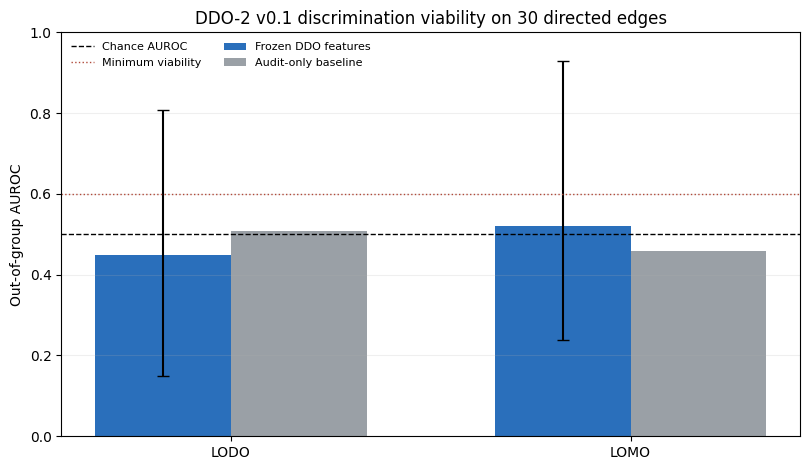

================ STAGE 11G-R COMPLETE ================
Edges / modalities / datasets: 30 / 4 / 14
Discrimination failures / passes: 19 / 11
LODO DDO AUROC / AP / Brier: 0.4498 / 0.5916 / 0.2667
LOMO DDO AUROC / AP / Brier: 0.5215 / 0.6332 / 0.2489
Viability gates passed: 0 / 6
DDO-2 v0.1 discrimination viable: False
Decision: TERMINATE_DDO2_V0_1_PREDICTIVE_LAW_ROUTE_DO_NOT_ACQUIRE_MORE_EDGES_SOLELY_TO_REPAIR_CLASS_COUNTS
Protocol seal: 09c5ad0a7dbba2fe5b27feb1d22692185b68c761591ac08d209892c6e6ebc96d
Performance hash: 10526c3a8bc85cbd569861a9f3ad5283be91cc526ebc945ba3266dd524f18413
Decision hash: f20fce117a9a1a8f18f98e0933e52b2e4388955e37cccc751e8cb2e6bb05ca52
Final record hash: 73095117b9a979c053c025fea984ac71501d459fb275baffb87fc6a8d72cd4dc
Next step: PIVOT_PROJECT_TO_SOURCE_ELIGIBILITY_AND_DIAGNOSTIC_OBSERVABILITY_MEASUREMENT_OR_REDESIGN_FEATURES_UNDER_A_NEW_PROJECT_PROTOCOL


In [6]:
# @title 11G-R-5. Save the decision figure, report, integrity manifest, and final record
import matplotlib.pyplot as plt
performance=pd.read_csv(PERFORMANCE); gates=pd.read_csv(GATES); decision_record=verify_self(DECISION,'decision_sha256')
primary=performance[performance.model=='DDO_FROZEN_DISCRIMINATION'].set_index('scheme')
audit_base=performance[performance.model=='AUDIT_ONLY_BASELINE'].set_index('scheme')
bootstrap=pd.read_csv(BOOTSTRAP)

fig,ax=plt.subplots(figsize=(8.2,4.8)); schemes=['LODO','LOMO']; x=np.arange(2); width=.34
ddo=[primary.loc[s,'auroc'] for s in schemes]; base=[audit_base.loc[s,'auroc'] for s in schemes]
lo=[v-bootstrap[bootstrap.scheme==s].ddo_auroc.quantile(.025) for v,s in zip(ddo,schemes)]
hi=[bootstrap[bootstrap.scheme==s].ddo_auroc.quantile(.975)-v for v,s in zip(ddo,schemes)]
ax.bar(x-width/2,ddo,width,label='Frozen DDO features',color='#2a6fbb',yerr=[lo,hi],capsize=4)
ax.bar(x+width/2,base,width,label='Audit-only baseline',color='#9aa0a6')
ax.axhline(.5,color='black',ls='--',lw=1,label='Chance AUROC'); ax.axhline(.6,color='#b04a3a',ls=':',lw=1,label='Minimum viability')
ax.set_xticks(x,schemes); ax.set_ylim(0,1); ax.set_ylabel('Out-of-group AUROC'); ax.set_title('DDO-2 v0.1 discrimination viability on 30 directed edges')
ax.legend(frameon=False,ncol=2,fontsize=8); ax.grid(axis='y',alpha=.2); fig.tight_layout(); fig.savefig(FIGURE,dpi=180,bbox_inches='tight'); plt.show(); plt.close(fig)

answer=('The frozen DDO discrimination features cleared every development viability gate.' if decision_record['discrimination_viable'] else
        'The frozen DDO discrimination features did not clear the grouped development viability gates; DDO-2 v0.1 is terminated as a predictive-law route.')
report=f"""# Stage 11G-R — decisive DDO-2 v0.1 viability report

## Answer first

**{answer}**

**Decision:** `{decision_record['decision']}`

This result uses the sealed 30-edge, 4-modality, 14-dataset Stage 11F-R development library. It is a retrospective development kill test, not independent blind validation.

## Grouped performance

{mdtable(performance)}

## Pre-run viability gates

{mdtable(gates)}

## Interpretation

- Calibration and operating-point models were not fitted because their Stage 9 class-balance gates failed.
- The discrimination axis had 19 failures and 11 passes across all four modalities, so its lack or presence of grouped signal can be tested without first acquiring more edges.
- The audit-only baseline was fixed before execution; no feature or regularisation search was performed.
- The fifth breast-ultrasound dataset was not repaired in this notebook. Its known adapter defect (using `Diagnosis` rather than `Classification`) matters only if the core discrimination route remains viable.
- No Stage 12 or locked-blind asset was accessed.

## Next step

`{decision_record['next_step']}`
"""
write_text(REPORT,report)
tracked=[]
for p in sorted(ROOT.rglob('*')):
    if p.is_file() and p not in {RUNTIME,MANIFEST,FINAL}:
        tracked.append({'relative_path':str(p.relative_to(ROOT)),'size_bytes':p.stat().st_size,'sha256':sha_file(p)})
manifest=pd.DataFrame(tracked); write_csv(MANIFEST,manifest)
final_payload={'stage':'Stage11G-R','decision':decision_record['decision'],'protocol_seal_sha256':protocol['seal_sha256'],
    'parent_stage11f_r_final_sha256':parent['final_record_sha256'],'parent_library_sha256':sha_file(PARENT_LIBRARY),
    'performance_sha256':sha_file(PERFORMANCE),'gates_sha256':sha_file(GATES),'decision_sha256':decision_record['decision_sha256'],
    'firewall_sha256':sha_file(FIREWALL),'figure_sha256':sha_file(FIGURE),'report_sha256':sha_file(REPORT),
    'output_integrity_manifest_sha256':sha_file(MANIFEST),'eligible_edges':30,'modalities':4,'unique_datasets':14,
    'discrimination_failures':19,'discrimination_passes':11,'discrimination_viable':decision_record['discrimination_viable'],
    'hierarchical_ddo2_fitted':False,'stage12_authorised':False,'locked_blind_assets_touched':False,
    'next_step':decision_record['next_step']}
final=seal(FINAL,final_payload,'final_record_sha256','completed_utc')
runtime.update({'completed':True,'decision':final['decision'],'final_record_sha256':final['final_record_sha256'],'last_updated_utc':now()})
RUNTIME.write_text(json.dumps(runtime,indent=2)+'\n')
print('================ STAGE 11G-R COMPLETE ================')
print('Edges / modalities / datasets:',final['eligible_edges'],'/',final['modalities'],'/',final['unique_datasets'])
print('Discrimination failures / passes:',final['discrimination_failures'],'/',final['discrimination_passes'])
for scheme in ['LODO','LOMO']:
    row=performance[(performance.scheme==scheme)&(performance.model=='DDO_FROZEN_DISCRIMINATION')].iloc[0]
    print(f'{scheme} DDO AUROC / AP / Brier:',f"{row.auroc:.4f}",'/',f"{row.average_precision:.4f}",'/',f"{row.brier:.4f}")
print('Viability gates passed:',int(gates.passed.sum()),'/',len(gates))
print('DDO-2 v0.1 discrimination viable:',final['discrimination_viable'])
print('Decision:',final['decision'])
print('Protocol seal:',final['protocol_seal_sha256'])
print('Performance hash:',final['performance_sha256'])
print('Decision hash:',final['decision_sha256'])
print('Final record hash:',final['final_record_sha256'])
print('Next step:',final['next_step'])
